In [2]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time
import math

# 1 

In [132]:
N = 10_00
m = 10
A =8 

g = lambda A,i: (A**i)/math.factorial(i) 

X = np.zeros(N+1,dtype=int)
X[0] = 1
for i in range(N):
    Y = np.random.randint(0,m+1)
    ratio = g(A,Y)/g(A,X[i])
    alpha =  min(1, ratio)
    if np.random.rand() < alpha:
        X[i+1] = Y
    else: X[i+1] = X[i]

M_array = np.arange(0,m+1,dtype=int)
g_correct = np.zeros_like(M_array,dtype=int)
for i in range(m+1):
    g_correct[i] = g(A,M_array[i])

array = g_correct/np.sum(g_correct)

In [166]:
g_correct

array([  1,   8,  32,  85, 170, 273, 364, 416, 416, 369, 295])

<BarContainer object of 11 artists>

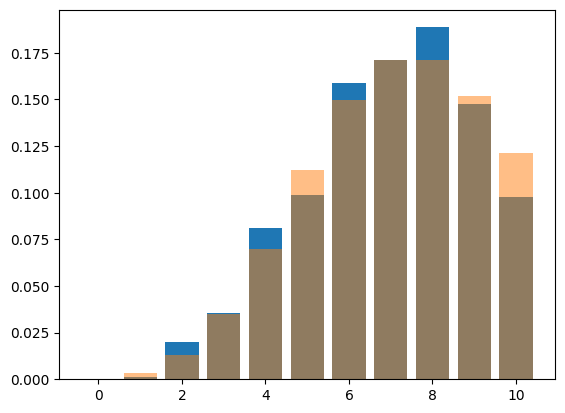

In [160]:
counts = np.bincount(X[100::], minlength=m)  
preditic_prob = counts/np.sum(counts)
plt.bar(np.arange(m+1), preditic_prob)  
plt.bar(np.arange(m+1), array, alpha=0.5)       
# m = 9

In [161]:
chi = np.sum((preditic_prob-array)**2 / array)
p = 1- ss.chi2.cdf(chi,df = 10)
ss.chisquare(preditic_prob,array,ddof=0)

Power_divergenceResult(statistic=np.float64(0.015842056563615377), pvalue=np.float64(0.9999999999997419))

# 2

In [189]:
import numpy as np, math

N = 10_000-1
m = 10
A1 = 4
A2 = 4

g = lambda A1, A2, i, j: (A1**i)/math.factorial(i) * (A2**j)/math.factorial(j)

X = np.zeros((N+1, 2), dtype=int)      
X[0] = [0, 0]

for i in range(N):
    Y1 = np.random.randint(0, m+1)
    Y2 = np.random.randint(0, m+1)
    while Y1 + Y2 > m:                 
        Y1 = np.random.randint(0, m+1)
        Y2 = np.random.randint(0, m+1)

    ci, cj = X[i]                     
    ratio = g(A1, A2, Y1, Y2) / g(A1, A2, ci, cj)
    if np.random.rand() < min(1, ratio):
        X[i+1] = [Y1, Y2]
    else:
        X[i+1] = X[i]

M_array = np.arange(0,m+1,dtype=int)
g_correct = np.zeros((m+1,m+1))
for i in range(m+1):
    for j in range(m+1):
        if j+i <= m:
            g_correct[i][j] = g(A1,A2,M_array[i],M_array[j])
        else: continue

array = g_correct/np.sum(g_correct)

In [197]:
count = np.zeros((m+1, m+1))
for ci, cj in X:      
    count[ci][cj] += 1   

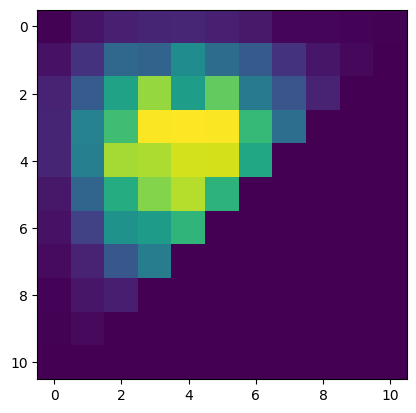

In [202]:
plt.imshow(count/np.sum(count))

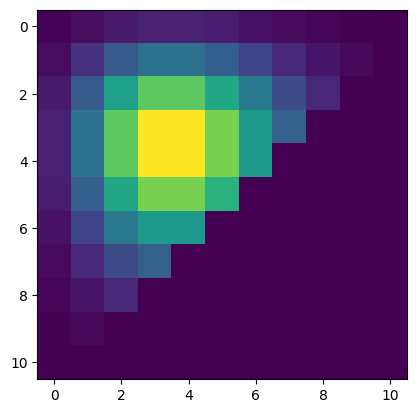

In [199]:
plt.imshow(array)

In [204]:
probs_predict = count/np.sum(count)

In [ ]:
mask = array.flatten() > 0
chi = np.sum((probs_predict.flatten()[mask] - array.flatten()[mask])**2 / array.flatten()[mask])
p = 1 - ss.chi2.cdf(chi, df=np.count_nonzero(mask) - 1)
chi2_result = ss.chisquare(probs_predict.flatten()[mask], array.flatten()[mask], ddof=0)
chi, p, chi2_result

C:\Users\fedtm\AppData\Local\Temp\ipykernel_2104\1961032841.py:1: RuntimeWarning: invalid value encountered in divide
  chi = np.sum((probs_predict.flatten()-array.flatten())**2 / array.flatten())
c:\Users\fedtm\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_stats_py.py:7632: RuntimeWarning: divide by zero encountered in divide
  relative_diff = (xp.abs(f_obs_sum - f_exp_sum) /


ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
[           inf 6.29522300e+00 2.50363455e-01 7.19457264e-01
 3.18512399e+00 6.22444854e+00 2.07393090e+01 5.84356948e+01
 2.37890721e+02 1.09234662e+03 9.04171642e+03]